<a href="https://colab.research.google.com/github/carneiro-santos/dataton_fase_5_/blob/main/fase_5_FIAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Datathon Fase 5

### nesta primeira etapa, tratamento dos dados

In [2]:
import pandas as pd
import numpy as np
import re
import unicodedata

pd.set_option('display.max_columns', None)

### carregamento da tabela

In [3]:
file_name = '/content/Tabela Geral Sheets-4.xlsx'

xls = pd.ExcelFile(file_name)

df_2022 = pd.read_excel(xls, sheet_name='2022')
df_2023 = pd.read_excel(xls, sheet_name='2023')
df_2024 = pd.read_excel(xls, sheet_name='2024')

print(df_2022.shape, df_2023.shape, df_2024.shape)

(860, 42) (1014, 50) (1156, 51)


### exploracao dos dados

In [4]:
for nome, df in zip(['2022','2023','2024'], [df_2022, df_2023, df_2024]):
    print(f"\n==== {nome} ====")
    print(df.columns.tolist())


==== 2022 ====
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

==== 2023 ====
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Unnamed: 7', 'Idade', 'Unnamed: 9', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', '

## Padronizacao das colunas

In [5]:
def remover_acentos(texto):
    return unicodedata.normalize('NFKD', str(texto)).encode('ASCII', 'ignore').decode('utf-8')

def ajustar_colunas(df, ano):

    df.columns = [remover_acentos(col).strip() for col in df.columns]

    rename_map = {}

    for col in df.columns:
        c = col.lower()

        if 'inde' in c: rename_map[col] = 'INDE'
        elif 'ida' in c: rename_map[col] = 'IDA'
        elif 'ieg' in c: rename_map[col] = 'IEG'
        elif 'iaa' in c: rename_map[col] = 'IAA'
        elif 'ips' in c: rename_map[col] = 'IPS'
        elif 'ipp' in c: rename_map[col] = 'IPP'
        elif 'ian' in c: rename_map[col] = 'IAN'
        elif 'ipv' in c: rename_map[col] = 'IPV'

        elif c == 'mat': rename_map[col] = 'Nota_Mat'
        elif c == 'por': rename_map[col] = 'Nota_Por'
        elif c == 'ing': rename_map[col] = 'Nota_Ing'

        elif 'pedra' in c: rename_map[col] = 'Pedra'
        elif 'genero' in c: rename_map[col] = 'Genero'
        elif 'idade' in c: rename_map[col] = 'Idade'
        elif 'instituicao' in c or 'escola' in c: rename_map[col] = 'Instituicao'
        elif 'ingresso' in c: rename_map[col] = 'Ano_Ingresso'
        elif c == 'ra': rename_map[col] = 'RA'
        elif 'fase' in c: rename_map[col] = 'Fase'

    df = df.rename(columns=rename_map)

    df = df.loc[:, ~df.columns.duplicated()]

    df['Ano_Base'] = ano

    return df

### aplicando a padronizacao na tabela

In [6]:
df_2022 = ajustar_colunas(df_2022, 2022)
df_2023 = ajustar_colunas(df_2023, 2023)
df_2024 = ajustar_colunas(df_2024, 2024)

### Padronizacao da fase

In [7]:
def padronizar_fase(valor):

    if pd.isna(valor):
        return np.nan

    v = str(valor).strip().upper()

    if v in ['ALFA','FASE 1','FASE 2','FASE 3','FASE 4',
             'FASE 5','FASE 6','FASE 7','FASE 8']:
        return v

    match = re.search(r'\d+', v)

    if match:
        num = int(match.group())

        if num == 0:
            return 'ALFA'
        elif 1 <= num <= 8:
            return f'FASE {num}'
        else:
            return 'FASE 8'

    return v

for df in [df_2022, df_2023, df_2024]:
    if 'Fase' in df.columns:
        df['Fase'] = df['Fase'].apply(padronizar_fase)

### concatenacao

In [8]:
df_full = pd.concat([df_2022, df_2023, df_2024], ignore_index=True, sort=False)

print(df_full.shape)

(3030, 49)


## Convertendo tipo de dados

In [9]:
cols_num = [
    'INDE','IAN','IDA','IEG','IAA','IPS','IPP','IPV',
    'Nota_Mat','Nota_Por','Nota_Ing','Idade'
]

for col in cols_num:
    if col in df_full.columns:
        df_full[col] = (
            df_full[col].astype(str)
            .str.replace(',', '.', regex=False)
        )
        df_full[col] = pd.to_numeric(df_full[col], errors='coerce')

## Limpeza de categorias

In [10]:
# Pedra
df_full['Pedra'] = df_full['Pedra'].astype(str).str.capitalize()

# Gênero
df_full['Genero'] = df_full['Genero'].astype(str).str.capitalize()

genero_fix = {'Menino':'Masculino','Menina':'Feminino'}
df_full['Genero'] = df_full['Genero'].replace(genero_fix)

# FEATURE ENGINEERING

In [11]:
# Tempo no programa
df_full['Tempo_Programa'] = df_full['Ano_Base'] - df_full['Ano_Ingresso']

# Pedra numérica
mapa = {'Quartzo':1,'Ágata':2,'Ametista':3,'Topázio':4}
df_full['Pedra_Num'] = df_full['Pedra'].map(mapa)

# Fase numérica
def fase_num(x):
    if pd.isna(x): return np.nan
    if 'ALFA' in x: return 0
    return int(x.replace('FASE ', ''))

df_full['Fase_Num'] = df_full['Fase'].apply(fase_num)

# Target
df_full['Risco'] = (df_full['IAN'] < 10).astype(int)

# Validacao

In [12]:
print(df_full.shape)

print("\nAnos:")
print(df_full['Ano_Base'].value_counts())

print("\nMissing:")
print(df_full.isnull().mean().sort_values(ascending=False).head(10))

print("\nNotas 2024:")
display(df_full[df_full['Ano_Base']==2024][[
    'Nota_Mat','Nota_Por','Nota_Ing'
]].head())

(3030, 53)

Anos:
Ano_Base
2024    1156
2023    1014
2022     860
Name: count, dtype: int64

Missing:
Avaliador6    0.998020
Avaliador5    0.951155
Ingles        0.906601
Rec Av4       0.902310
Nota_Ing      0.733333
Matem         0.716832
Portug        0.716832
Rec Av2       0.716172
Ano nasc      0.716172
Nome          0.716172
dtype: float64

Notas 2024:


,Nota_Mat,Nota_Por,Nota_Ing
1874,10.0,6.0,NaN
1875,10.0,6.0,NaN
1876,10.0,6.0,NaN
1877,8.0,6.0,NaN
1878,8.0,7.0,NaN


# Exportacao da base

In [13]:
df_full.to_excel('/content/base_final.xlsx', index=False)

# Analise Exploratorio da base de dados

 1. Análise Exploratória - Passos Mágicos
 2. Análise Exploratória - Passos Mágicos

## Perfil de Defasagem
### quantos alunos estao em risco

In [14]:
df_full['Risco'] = df_full['IAN'] < 10

df_full['Risco'].value_counts(normalize=True)

,proportion
Risco,
True,0.556766
False,0.443234


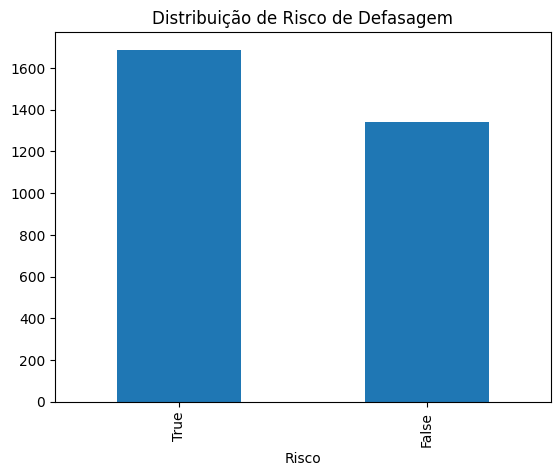

In [15]:
import matplotlib.pyplot as plt

df_full['Risco'].value_counts().plot(kind='bar')
plt.title('Distribuição de Risco de Defasagem')
plt.show()

## Evolucao do INDE

In [16]:
df_full.groupby('Ano_Base')['INDE'].mean()

,INDE
Ano_Base,
2022,7.036176
2023,7.342309
2024,7.396686


In [17]:
df_full['Ano_Base'] = df_full['Ano_Base'].astype(int)

### Evolucao do INDE ao longo dos anos grafico

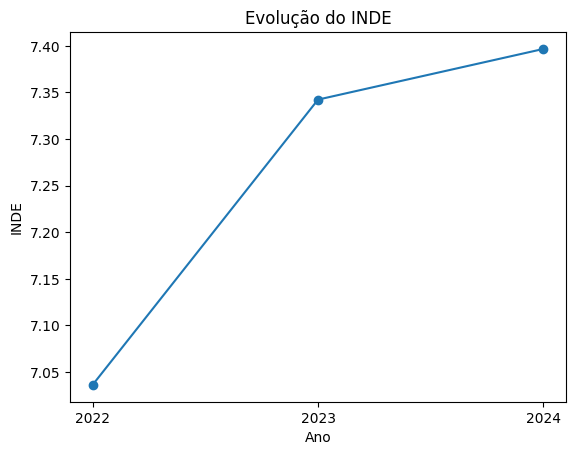

In [18]:
df_plot = df_full.groupby('Ano_Base')['INDE'].mean().reset_index()

plt.plot(df_plot['Ano_Base'].astype(str), df_plot['INDE'], marker='o')
plt.title('Evolução do INDE')
plt.xlabel('Ano')
plt.ylabel('INDE')
plt.show()

### Observamos evolução no desempenho médio dos alunos, indicando impacto positivo do programa.

## Engajamento vs Desempenho


### Engajamento influencia no desempenho?

In [19]:
df_full[['IEG','IDA','INDE']].corr()

,IEG,IDA,INDE
IEG,1.000000,-0.516338,0.74533
IDA,-0.516338,1.000000,-0.28669
INDE,0.745330,-0.286690,1.00000


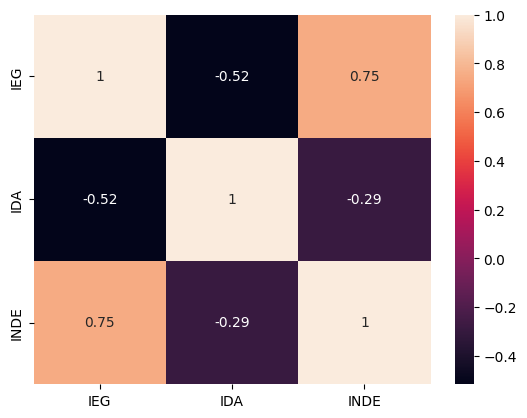

In [20]:
import seaborn as sns

sns.heatmap(df_full[['IEG','IDA','INDE']].corr(), annot=True)
plt.show()

### O engajamento apresenta forte correlação com o desempenho acadêmico, sendo um dos principais drivers de evolução.

In [21]:
df_full[['IAA','IDA','IEG']].corr()

,IAA,IDA,IEG
IAA,1.000000,-0.133463,0.133078
IDA,-0.133463,1.000000,-0.516338
IEG,0.133078,-0.516338,1.000000


In [22]:
df_full[['IPS','INDE','IEG']].corr()

,IPS,INDE,IEG
IPS,1.000000,0.199618,-0.046264
INDE,0.199618,1.000000,0.745330
IEG,-0.046264,0.745330,1.000000


In [23]:
df_full.groupby('Pedra')['INDE'].mean().sort_values()

,INDE
Pedra,
Quartzo,5.473233
Ágata,6.187196
Agata,6.583902
Nan,7.092639
Ametista,7.437112
Topázio,8.389697
Incluir,NaN


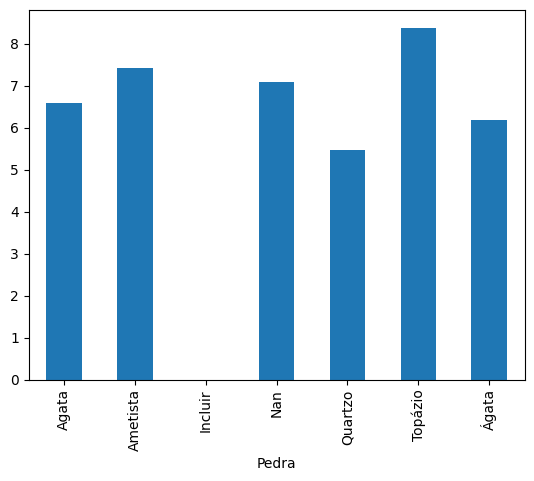

In [24]:
df_full.groupby('Pedra')['INDE'].mean().plot(kind='bar')
plt.show()

#INDE por Genero

In [25]:
df_full.groupby('Genero')['INDE'].mean()

,INDE
Genero,
Feminino,7.337838
Masculino,7.192105


In [26]:
df_full.groupby('Idade')['INDE'].mean()

KeyError: 'Idade'

In [27]:
df_full.groupby('Instituicao')['INDE'].mean().sort_values()

,INDE
Instituicao,
Privada - Programa de apadrinhamento,5.107590
Escola JP II,5.477000
Escola Pública,6.940867
Pública,7.315242
Concluiu o 3º EM,7.326646
Nenhuma das opções acima,7.368667
Privada,7.419869
Rede Decisão,7.741745
Privada - Programa de Apadrinhamento,7.863056


In [28]:
df_full[['Nota_Mat','Nota_Por','Nota_Ing','INDE']].corr()

,Nota_Mat,Nota_Por,Nota_Ing,INDE
Nota_Mat,1.000000,0.458531,0.416610,0.631672
Nota_Por,0.458531,1.000000,0.449119,0.625633
Nota_Ing,0.416610,0.449119,1.000000,0.646332
INDE,0.631672,0.625633,0.646332,1.000000


In [29]:
df_full.groupby('Risco')[['IEG','IPS','IDA']].mean()

,IEG,IPS,IDA
Risco,,,
False,7.776492,6.286179,12.657216
True,8.073126,6.287794,12.461486
